In [1]:
# Import Packages
import os
import re
import sys
import time
import copy
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import boxcox

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.model_selection import RepeatedKFold

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV

from sklearn.feature_selection import VarianceThreshold

from itertools import product

#%load_ext autoreload
#%reload_ext autoreload
#%autoreload 2
#from model_functions import *

%run Model_functions.ipynb

In [2]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

!chmod 644 ~/.local/share/jupyter/history.sqlite
#!rm ~/.local/share/jupyter/history.sqlite

chmod: /Users/kosaraju_b/.local/share/jupyter/history.sqlite: No such file or directory


# DOWNLOAD SENTINEL-AGB DATA

In [3]:
SENTINEL_DATA_CSV        = "../../DATA/AGB_DATA/Merged_Data/Sentinel_AGB/AGB_SENTINEL_CANOPY.csv"
#SENINEL_MISSING_DATA_CSV = "../../DATA/AGB_DATA/Merged_Data/Sentinel_AGB/AGB_VAL_EO_SENTINEL.csv"

sentinel_df = pd.read_csv(SENTINEL_DATA_CSV)
print(sentinel_df.shape)
sentinel_df.columns

(8774, 34)


Index(['dataset', 'plot_id', 'start_date', 'end_date', 'latitude', 'longitude',
       'diameter', 'height', 'species', 'plant_AGB_kg', 'capture_start',
       'capture_end', 'sentinel_time', 'Blue', 'Green', 'Red', 'RE1', 'RE2',
       'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1',
       'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'cloud_threshold_used',
       'simard_height_m', 'tandemx_height_m'],
      dtype='object')

In [4]:
assert len(sentinel_df["simard_height_m"].head())
assert len(sentinel_df["tandemx_height_m"].head())

In [5]:
sentinel_df['dataset'].unique()

array(['ElSalvador', 'Panama-Chirqui_2', 'CostaRica-Nicoya',
       'CostaRica-Sierpe', 'Belige', 'Panama-Chirqui_1',
       'Honduras-Blanca', 'Brazil-Mangue', 'Brazil-Furo_Do_Chato',
       'Brazil-Manguezal', 'Brazil-Maruipe', 'Brazil-AcarauBoca',
       'Brazil-BocaGrande', 'Brazil-Barreto', 'Brazil-Salinas',
       'Brazil-FuroGrande', 'Brazil-Caetano'], dtype=object)

### Select features

In [6]:
belige_df = sentinel_df[sentinel_df['dataset'] == 'Belige'].copy()
assert len(belige_df['simard_height_m'].head())
assert len(belige_df['tandemx_height_m'].head())

non_feature_cols = [
    #'plant_AGB_kg',        # Target variable
    'dataset',             # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    #'latitude',            # coordinate
    #'longitude',           # coordinate
    'diameter',            # Allometric
    'height',               # Allometric
    'cloud_threshold_used'
]
sentinel_bands = [
    'Blue', 'Green', 'Red'
]
sentinel_indices = [
    'NIR', 'SWIR1', 'SWIR2', 'NDVI',
    'MNDWI', 'NBR', 'EVI', 'CLOUD_COVERAGE'
]
useful_categorical = ['plot_id', 'species']
struct_features = ['height']

target = 'plant_AGB_kg'
feature_cols = [c for c in sentinel_df.columns if c not in non_feature_cols]

X = belige_df[feature_cols]
y = belige_df[target]

# Select TANDEMX
X = X.rename({'tandemx_height_m': 'height'}, axis=1)
X = X.drop(columns=['simard_height_m'])

# Select SIMARD
#X = X.rename({'simard_height_m': 'height'}, axis=1)
#X = X.drop(columns=['tandemx_height_m'])

print(f"Features: {feature_cols}")

Features: ['plot_id', 'latitude', 'longitude', 'species', 'plant_AGB_kg', 'sentinel_time', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'simard_height_m', 'tandemx_height_m']


In [7]:
# Retain the groups/plot_id for splitting the data based on groups.
plot_groups = X['plot_id'].copy()
site_groups = plot_groups.map(lambda x: x.rsplit('_', maxsplit=1)[0])

## DATA PREPROCESSING

In [8]:
null_rows   = X[X.isnull().any(axis=1)]
total_nulls = X.isnull().sum().sum()

print(f"Total NULL count           : {total_nulls}")
print(f"Rows with at least one NULL: {len(null_rows)}")
print(f"Total rows                 : {len(sentinel_df)}")
print(f"Percentage                 : {len(null_rows)/len(sentinel_df)*100:.1f}%")

# NULL count per column for only the affected rows
null_col_counts = null_rows.isnull().sum().sort_values(ascending=False)
print("\nNULL count per column in affected rows:")
print(null_col_counts[null_col_counts > 0])

Total NULL count           : 0
Rows with at least one NULL: 0
Total rows                 : 8774
Percentage                 : 0.0%

NULL count per column in affected rows:
Series([], dtype: int64)


In [9]:
assert not total_nulls
#sentinel_df = handle_null_data(sentinel_df)
#X = X.dropna()
#print(X.shape)
#X.columns

### Find correlations

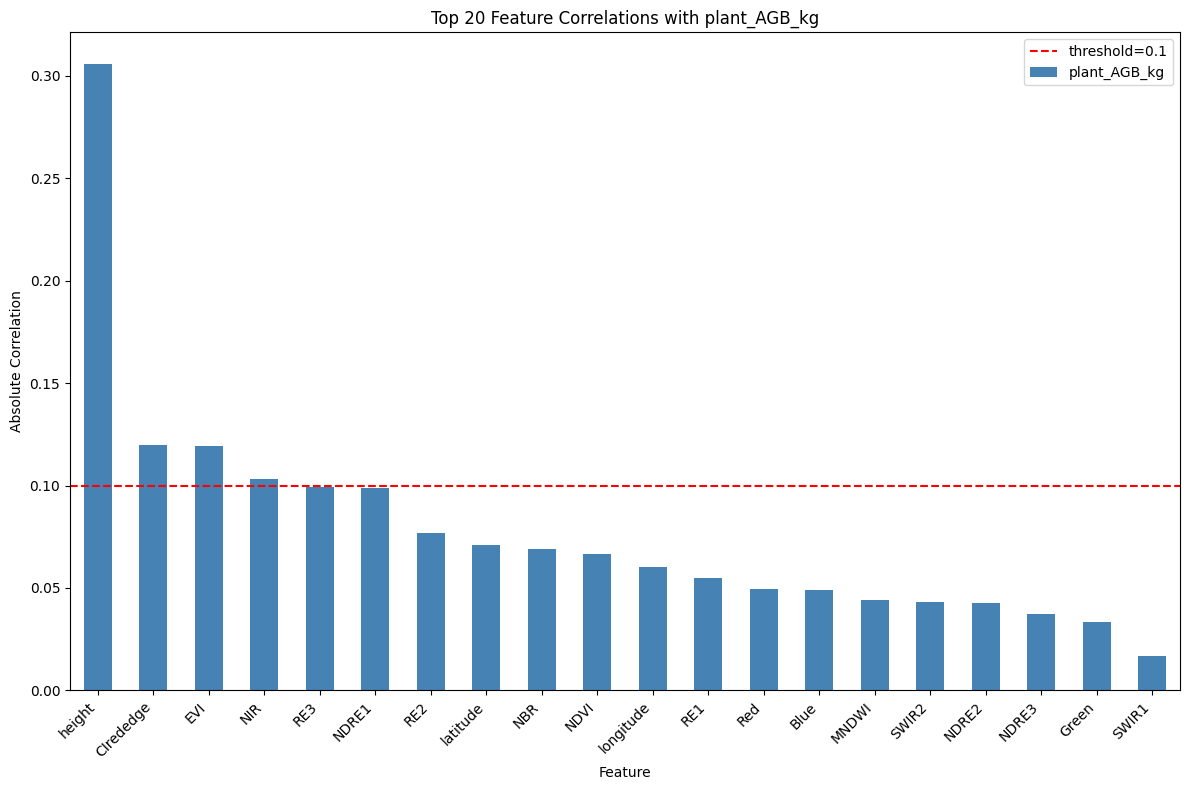

height       0.305997
CIrededge    0.119717
EVI          0.119078
NIR          0.103383
RE3          0.099264
NDRE1        0.098902
RE2          0.076811
latitude     0.071156
NBR          0.068840
NDVI         0.066806
longitude    0.060221
RE1          0.054646
Red          0.049271
Blue         0.048902
MNDWI        0.044189
SWIR2        0.043206
NDRE2        0.042639
NDRE3        0.037197
Green        0.033607
SWIR1        0.016703
Name: plant_AGB_kg, dtype: float64


In [10]:
numerical_cols = get_numerical_cols(X)
target_corr = plot_correlation_matrix(X[numerical_cols],
                                      X['plant_AGB_kg'],
                                      top_n=20)
print(target_corr)

**COMMENTS:**  
Columns with a Pearson correlation coefficient (r) between -0.1 and 0.1 with the target variable are generally considered to have a negligible or very weak relationship.

### Remove Low Variance Features (cols)

#### Is variance threshold valid for sentinel-2 data?

- Sentinel-2 surface reflectance values are typically in the range 0.0 to 0.3.  
 - Their absolute variance is naturally small — not because they carry no information but because their scale is small.  
 - A feature with values ranging from 0.05 to 0.25 has variance of ~0.003, which falls below the 0.01 threshold, but the variation within that range is meaningful for AGB prediction.  
 - VarianceThreshold is designed for features with near-identical values across all rows — like a binary column that is always 0.  
 - It is not appropriate for bounded continuous features like reflectance values.

### Remove Features With Weak Correlation to Target

#### Why Pearson correlation is unreliable here?

Pearson correlation measures linear relationship between a feature and the target. 

The above correlation removal process is based on the correlations computed against the original y. But we are going log-transform the target for modeling. 

A feature can have a strong non-linear relationship with AGB that shows up clearly after log transformation but appears weak in linear correlation against raw AGB.  

The experiments (Belige-data-analysis.ipynb) already proved these features are useful.  

In [11]:
X = remove_uncorrelated_categorical_cols(X, y)
assert X is not None

X.columns


--- plot_id ---
Variable  : plot_id
F-stat    : 21.7921
p-value   : 0.0000
Relevant? : True

--- species ---
Variable  : species
F-stat    : 45.2611
p-value   : 0.0000
Relevant? : True

--- sentinel_time ---
sentinel_time : skipped — fewer than 2 valid groups after filtering

         feature  relevant?
0        plot_id       True
1        species       True
2  sentinel_time      False


Strong correlations kept   : 24
Weak correlations removed: 1


Index(['plot_id', 'latitude', 'longitude', 'species', 'plant_AGB_kg', 'Blue',
       'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI',
       'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge',
       'CLOUD_COVERAGE', 'height'],
      dtype='object')

### Convert categorical variables to one-hot encoding

# What would actually constitute a good result?
For a model to be trustworthy you would want to see:
 - Grouped CV mean above 0.40
 - Grouped CV std below 0.15
 - No individual grouped CV fold below -0.10
 - Regular CV and grouped CV in the same ballpark — large divergence between them signals leakage
 - Test R² close to grouped CV mean, not far above it

**Determine near_zero_threshold, and high_agb_threshold**  
**near_zero_threshold = 1.0 kg**
 - Any site where the heaviest plant weighs less than 1 kg has near-zero AGB variance.
 - From your data Frenchman Caye (max 0.26 kg) and Shipstern (max 0.94 kg) fall below this.
 - R² is meaningless for these sites as a holdout set.
 - In other words, R² is mathematically unstable when the holdout set has near-zero variance.

**R² is defined as:** 1 - (sum of squared residuals / total sum of squares)
**Total sum of squares is (denominator):** sum of (y - mean(y))²
**Problem:**  
 - When every plant in the holdout site weighs between 0.001 and 0.26 kg, the mean is ~0.03 kg and every value is very close to that mean.
 - This makes the total sum of squares as near-zero.
 - Any prediction error, however small will produce a large negative R² because of the near-zero denominator.

**high_agb_threshold = 100.0 kg**
 - Any site with trees above 100 kg is potentially ecologically distinct from the rest.
 - From your data Channel Caye (max 427 kg) and New River (max 261 kg) fall above this.
 - These are the sites where generalization failure is a genuine concern.

In [12]:
%run Model_functions.ipynb

In [13]:
near_zero_sites, high_agb_sites, near_zero_plots, high_agb_plots = \
    get_low_and_high_agb_plots(y, plot_groups)

High-AGB threshold  : 104.49 kg
Near-zero threshold : 0.004134

Near-zero variance plots:
  Big Creek_1               : log var = 0.000036
  Big Creek_4               : log var = 0.000032
  Frenchman Caye_1          : log var = 0.000753
  Frenchman Caye_2          : log var = 0.000381
  Frenchman Caye_3          : log var = 0.000693
  Frenchman Caye_4          : log var = 0.001306
  Frenchman Caye_5          : log var = 0.001283
  Frenchman Caye_6          : log var = 0.000158
  Shipstern Lagoon_1        : log var = 0.001064
  Shipstern Lagoon_3        : log var = 0.000232
  Shipstern Lagoon_4        : log var = 0.000113
  Shipstern Lagoon_5        : log var = 0.000052
  Shipstern Lagoon_6        : log var = 0.000135

High-AGB plots:
  Channel Caye_1            : max AGB = 310.9 kg
  Channel Caye_2            : max AGB = 206.4 kg
  Channel Caye_3            : max AGB = 427.2 kg
  Channel Caye_4            : max AGB = 237.6 kg
  Channel Caye_5            : max AGB = 170.4 kg
  Channel C

In [14]:
top_spectral     = ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1']
redband_features = ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2']

features_list = [struct_features, 
                 useful_categorical + struct_features,
                 
                 sentinel_bands,
                 sentinel_indices,
                 sentinel_bands + sentinel_indices,
                 useful_categorical + sentinel_bands + sentinel_indices,
                 
                 useful_categorical + struct_features + sentinel_bands + sentinel_indices,
                 top_spectral,
                 redband_features]

model_list = ["regular", "ridge", "lasso", "elasticnet"]

test_cv = 5
#test_cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

# LINEAR REGRESSION

In [15]:
%run Model_functions.ipynb
lin_experiments = {}

In [16]:
def run_lin_experiment(model_type, X_df, y, features,
                       is_groups, groups, test_cv, idx,label_in):
    label = f"EXPERIMENT-{idx} {label_in}, Model: {model_type}, Features: {features}"
    
    X = X_df[features]
    categorical_cols = get_categorical_cols(X)
    if categorical_cols:
        X = pd.get_dummies(X, columns=categorical_cols, dtype=int)

    if is_groups:
        results = linear_reg_groups(model_type, X, y, test_cv, groups, label)
    else:
        results = linear_reg_regular(model_type, X, y, test_cv, label)
    lin_experiments[label] = results

    if is_groups:
        evaluate_experiment(label="",
                            results=results,
                            fold_sites=results["fold_sites"],
                            near_zero_sites=near_zero_sites,
                            high_agb_sites =high_agb_sites)
    else:
        evaluate_experiment(label="",
                            results=results,
                            fold_sites=None,
                            near_zero_sites=near_zero_plots,
                            high_agb_sites =high_agb_plots)

In [17]:
def lin_experiment(is_groups, groups, label):
    total     = len(features_list) * len(model_list)
    completed = 0

    for (feat_idx, features), (model_type) in product(enumerate(features_list), model_list):
        completed += 1
        print(f"\n[{completed}/{total}]")
    
        try:
            run_lin_experiment(model_type, X, y, features,
                               is_groups, groups, test_cv,
                               completed, label)        
        except Exception as e:
            print(f"  ERROR: {e}")
    
    print(f"\nCompleted: {completed}/{total} experiments")

### Linear regression without groups.


[1/36]


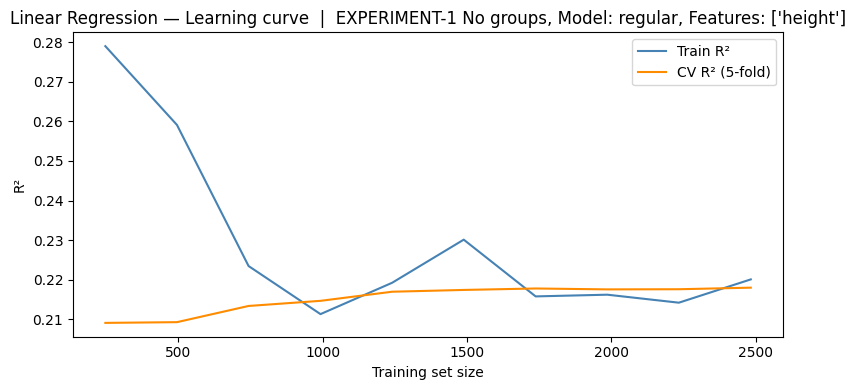


 EXPERIMENT-1 No groups, Model: regular, Features: ['height'], ALGO: LINEAR REGRESSION: 
Test R²     : 0.0131
Test RMSE   : 16.75 kg
Train R² (log scale): 0.2200
Train R² (orig scale): 0.0166
Train RMSE  : 16.59 kg
Num Features: 1

 Cross-validation ---
CV R² mean: 0.2180
CV R² std : 0.0168
CV scores : [0.23  0.221 0.186 0.233 0.221]
EXPERIMENT EVALUATION: 

Test set:
  R²   : 0.013
  RMSE : 16.75 kg

Regular CrossValidation:
  Mean   : 0.218
  Std    : 0.017
  Scores : [0.23  0.221 0.186 0.233 0.221]

  ✅ Test R² is positive (0.013)
  ✅ CV mean is positive (0.218)

────────────────────────────────────────────────────────────
VERDICT: ✅ ACCEPTABLE

[2/36]


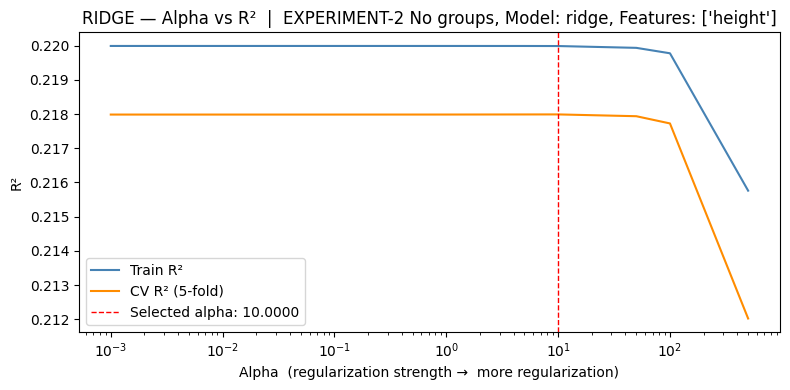

Selected alpha : 10.0

 EXPERIMENT-2 No groups, Model: ridge, Features: ['height'], ALGO: RIDGE REGRESSION: 
Test R²     : 0.0166
Test RMSE   : 16.72 kg
Train R² (log scale): 0.2200
Train R² (orig scale): 0.0181
Train RMSE  : 16.58 kg
Num Features: 1

 Cross-validation ---
CV R² mean: 0.2180
CV R² std : 0.0167
CV scores : [0.229 0.221 0.186 0.233 0.221]
EXPERIMENT EVALUATION: 

Test set:
  R²   : 0.017
  RMSE : 16.72 kg

Regular CrossValidation:
  Mean   : 0.218
  Std    : 0.017
  Scores : [0.229 0.221 0.186 0.233 0.221]

  ✅ Test R² is positive (0.017)
  ✅ CV mean is positive (0.218)

────────────────────────────────────────────────────────────
VERDICT: ✅ ACCEPTABLE

[3/36]


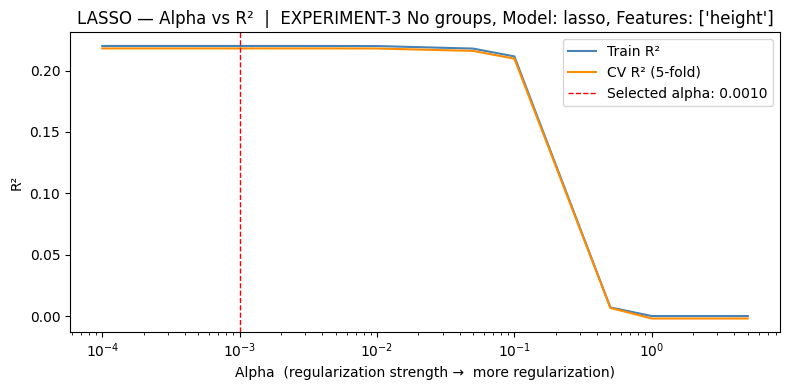

Selected alpha : 0.001

 EXPERIMENT-3 No groups, Model: lasso, Features: ['height'], ALGO: LASSO REGRESSION: 
Test R²     : 0.0153
Test RMSE   : 16.73 kg
Train R² (log scale): 0.2200
Train R² (orig scale): 0.0175
Train RMSE  : 16.59 kg
Num Features: 1

 Cross-validation ---
CV R² mean: 0.2180
CV R² std : 0.0167
CV scores : [0.23  0.221 0.186 0.233 0.221]
EXPERIMENT EVALUATION: 

Test set:
  R²   : 0.015
  RMSE : 16.73 kg

Regular CrossValidation:
  Mean   : 0.218
  Std    : 0.017
  Scores : [0.23  0.221 0.186 0.233 0.221]

  ✅ Test R² is positive (0.015)
  ✅ CV mean is positive (0.218)

────────────────────────────────────────────────────────────
VERDICT: ✅ ACCEPTABLE

[4/36]


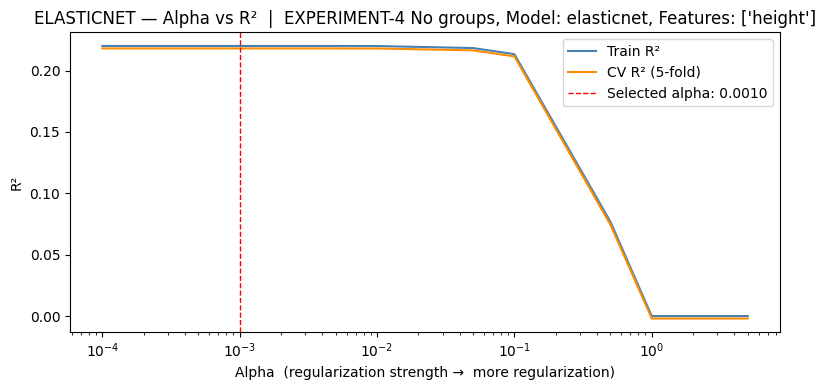

Selected alpha : 0.001

 EXPERIMENT-4 No groups, Model: elasticnet, Features: ['height'], ALGO: ELASTICNET REGRESSION: 
Test R²     : 0.0151
Test RMSE   : 16.73 kg
Train R² (log scale): 0.2200
Train R² (orig scale): 0.0174
Train RMSE  : 16.59 kg
Num Features: 1

 Cross-validation ---
CV R² mean: 0.2180
CV R² std : 0.0166
CV scores : [0.23  0.221 0.186 0.233 0.221]
EXPERIMENT EVALUATION: 

Test set:
  R²   : 0.015
  RMSE : 16.73 kg

Regular CrossValidation:
  Mean   : 0.218
  Std    : 0.017
  Scores : [0.23  0.221 0.186 0.233 0.221]

  ✅ Test R² is positive (0.015)
  ✅ CV mean is positive (0.218)

────────────────────────────────────────────────────────────
VERDICT: ✅ ACCEPTABLE

[5/36]


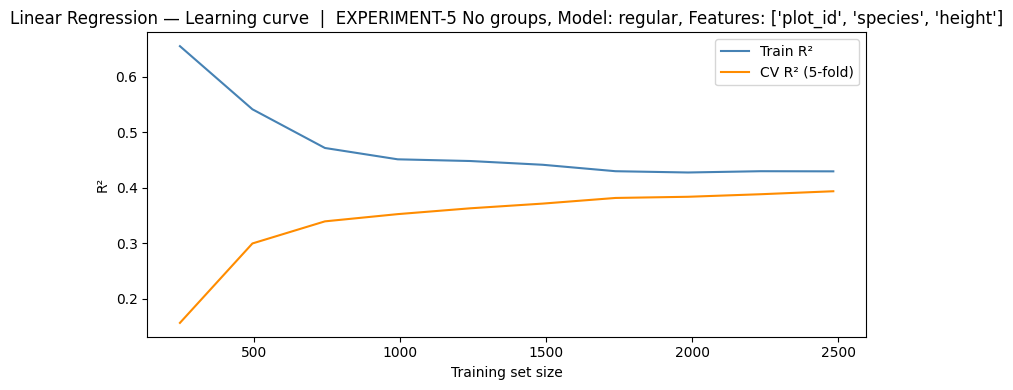


 EXPERIMENT-5 No groups, Model: regular, Features: ['plot_id', 'species', 'height'], ALGO: LINEAR REGRESSION: 
Test R²     : 0.1435
Test RMSE   : 15.60 kg
Train R² (log scale): 0.4265
Train R² (orig scale): 0.1973
Train RMSE  : 14.99 kg
Num Features: 63

 Cross-validation ---
CV R² mean: 0.3940
CV R² std : 0.0350
CV scores : [0.448 0.352 0.367 0.385 0.418]
EXPERIMENT EVALUATION: 

Test set:
  R²   : 0.143
  RMSE : 15.60 kg

Regular CrossValidation:
  Mean   : 0.394
  Std    : 0.035
  Scores : [0.448 0.352 0.367 0.385 0.418]

  ✅ Test R² is positive (0.143)
  ✅ CV mean is positive (0.394)

────────────────────────────────────────────────────────────
VERDICT: ✅ ACCEPTABLE

[6/36]


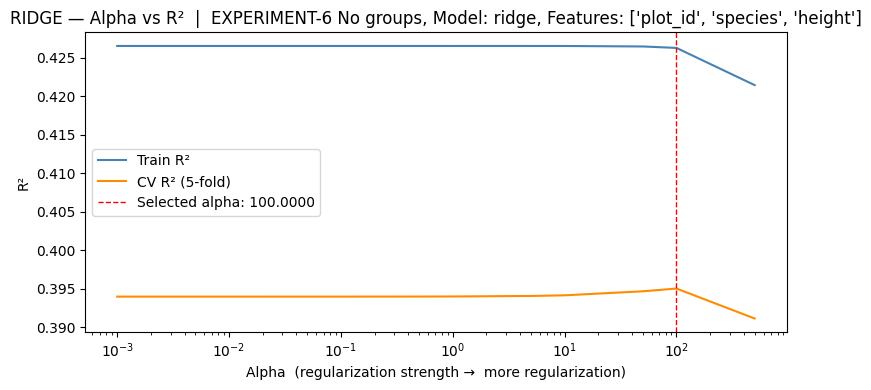

Selected alpha : 100.0

 EXPERIMENT-6 No groups, Model: ridge, Features: ['plot_id', 'species', 'height'], ALGO: RIDGE REGRESSION: 
Test R²     : 0.1448
Test RMSE   : 15.59 kg
Train R² (log scale): 0.4263
Train R² (orig scale): 0.1902
Train RMSE  : 15.06 kg
Num Features: 63

 Cross-validation ---
CV R² mean: 0.3950
CV R² std : 0.0324
CV scores : [0.445 0.355 0.371 0.387 0.418]
EXPERIMENT EVALUATION: 

Test set:
  R²   : 0.145
  RMSE : 15.59 kg

Regular CrossValidation:
  Mean   : 0.395
  Std    : 0.032
  Scores : [0.445 0.355 0.371 0.387 0.418]

  ✅ Test R² is positive (0.145)
  ✅ CV mean is positive (0.395)

────────────────────────────────────────────────────────────
VERDICT: ✅ ACCEPTABLE

[7/36]


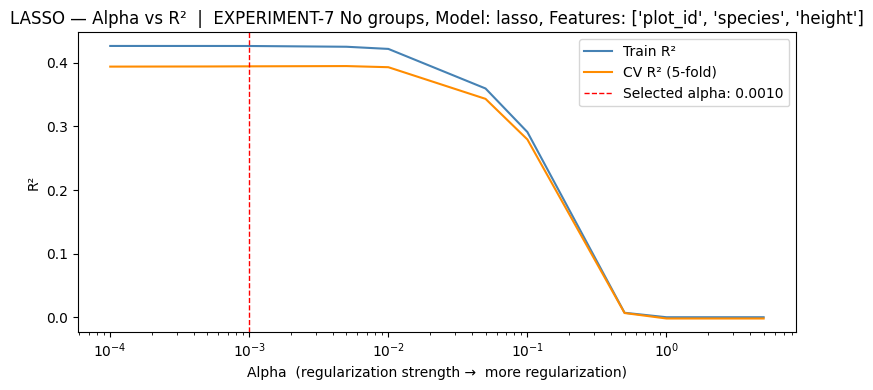

Selected alpha : 0.001

 EXPERIMENT-7 No groups, Model: lasso, Features: ['plot_id', 'species', 'height'], ALGO: LASSO REGRESSION: 
Test R²     : 0.1445
Test RMSE   : 15.60 kg
Train R² (log scale): 0.4265
Train R² (orig scale): 0.1964
Train RMSE  : 15.00 kg
Num Features: 63

 Cross-validation ---
CV R² mean: 0.3944
CV R² std : 0.0331
CV scores : [0.448 0.356 0.365 0.392 0.411]
EXPERIMENT EVALUATION: 

Test set:
  R²   : 0.144
  RMSE : 15.60 kg

Regular CrossValidation:
  Mean   : 0.394
  Std    : 0.033
  Scores : [0.448 0.356 0.365 0.392 0.411]

  ✅ Test R² is positive (0.144)
  ✅ CV mean is positive (0.394)

────────────────────────────────────────────────────────────
VERDICT: ✅ ACCEPTABLE

[8/36]


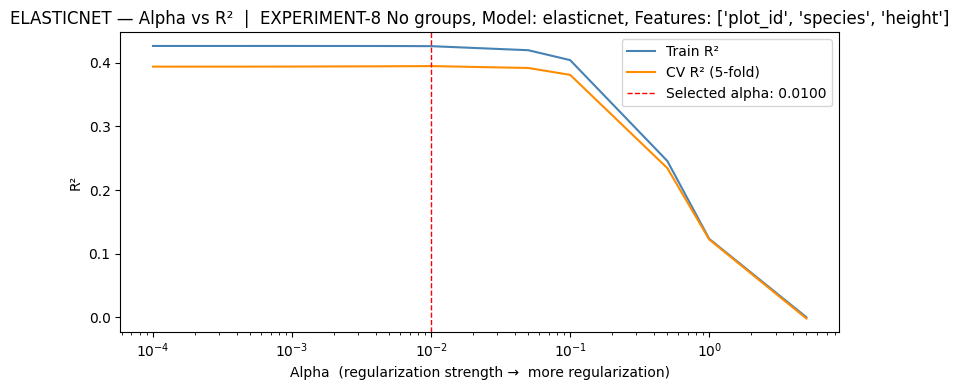

Selected alpha : 0.01

 EXPERIMENT-8 No groups, Model: elasticnet, Features: ['plot_id', 'species', 'height'], ALGO: ELASTICNET REGRESSION: 
Test R²     : 0.1444
Test RMSE   : 15.60 kg
Train R² (log scale): 0.4262
Train R² (orig scale): 0.1930
Train RMSE  : 15.03 kg
Num Features: 63

 Cross-validation ---
CV R² mean: 0.3952
CV R² std : 0.0330
CV scores : [0.447 0.355 0.369 0.39  0.415]
EXPERIMENT EVALUATION: 

Test set:
  R²   : 0.144
  RMSE : 15.60 kg

Regular CrossValidation:
  Mean   : 0.395
  Std    : 0.033
  Scores : [0.447 0.355 0.369 0.39  0.415]

  ✅ Test R² is positive (0.144)
  ✅ CV mean is positive (0.395)

────────────────────────────────────────────────────────────
VERDICT: ✅ ACCEPTABLE

[9/36]


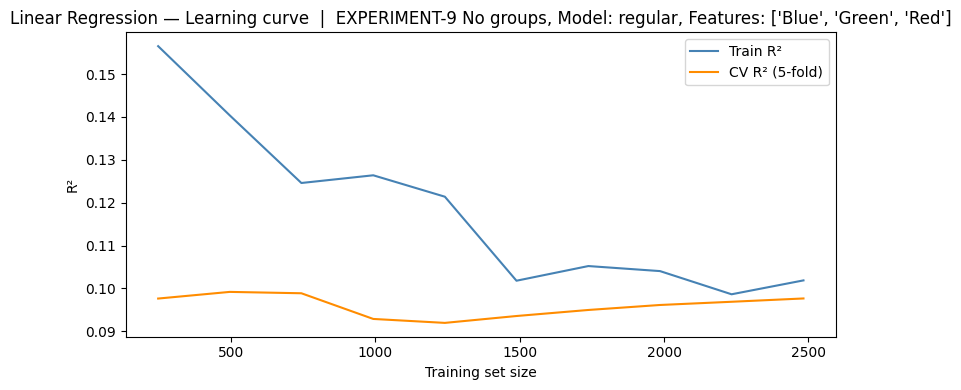


 EXPERIMENT-9 No groups, Model: regular, Features: ['Blue', 'Green', 'Red'], ALGO: LINEAR REGRESSION: 
Test R²     : -0.0361
Test RMSE   : 17.16 kg
Train R² (log scale): 0.1013
Train R² (orig scale): -0.0272
Train RMSE  : 16.96 kg
Num Features: 3

 Cross-validation ---
CV R² mean: 0.0977
CV R² std : 0.0449
CV scores : [0.12  0.154 0.018 0.09  0.106]
EXPERIMENT EVALUATION: 

Test set:
  R²   : -0.036
  RMSE : 17.16 kg

Regular CrossValidation:
  Mean   : 0.098
  Std    : 0.045
  Scores : [0.12  0.154 0.018 0.09  0.106]

  ❌ Test R² is negative (-0.036)
  ✅ CV mean is positive (0.098)

────────────────────────────────────────────────────────────
VERDICT: ❌ NOT ACCEPTABLE

[10/36]


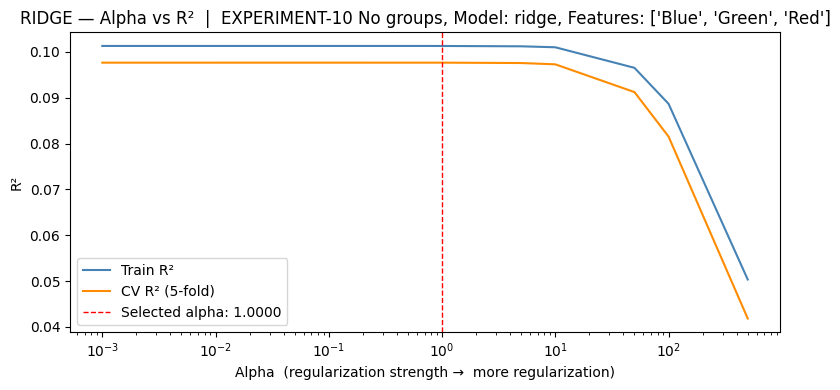

Selected alpha : 1.0

 EXPERIMENT-10 No groups, Model: ridge, Features: ['Blue', 'Green', 'Red'], ALGO: RIDGE REGRESSION: 
Test R²     : -0.0361
Test RMSE   : 17.16 kg
Train R² (log scale): 0.1013
Train R² (orig scale): -0.0272
Train RMSE  : 16.96 kg
Num Features: 3

 Cross-validation ---
CV R² mean: 0.0977
CV R² std : 0.0445
CV scores : [0.119 0.154 0.019 0.09  0.106]
EXPERIMENT EVALUATION: 

Test set:
  R²   : -0.036
  RMSE : 17.16 kg

Regular CrossValidation:
  Mean   : 0.098
  Std    : 0.044
  Scores : [0.119 0.154 0.019 0.09  0.106]

  ❌ Test R² is negative (-0.036)
  ✅ CV mean is positive (0.098)

────────────────────────────────────────────────────────────
VERDICT: ❌ NOT ACCEPTABLE

[11/36]


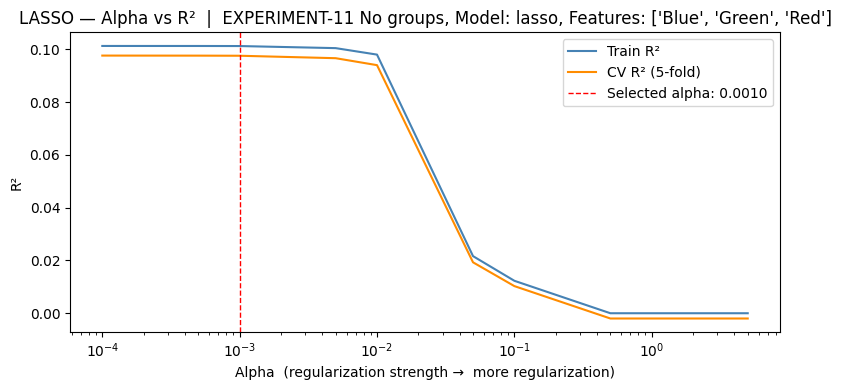

Selected alpha : 0.001

 EXPERIMENT-11 No groups, Model: lasso, Features: ['Blue', 'Green', 'Red'], ALGO: LASSO REGRESSION: 
Test R²     : -0.0363
Test RMSE   : 17.16 kg
Train R² (log scale): 0.1013
Train R² (orig scale): -0.0274
Train RMSE  : 16.96 kg
Num Features: 3

 Cross-validation ---
CV R² mean: 0.0976
CV R² std : 0.0440
CV scores : [0.119 0.153 0.02  0.09  0.106]
EXPERIMENT EVALUATION: 

Test set:
  R²   : -0.036
  RMSE : 17.16 kg

Regular CrossValidation:
  Mean   : 0.098
  Std    : 0.044
  Scores : [0.119 0.153 0.02  0.09  0.106]

  ❌ Test R² is negative (-0.036)
  ✅ CV mean is positive (0.098)

────────────────────────────────────────────────────────────
VERDICT: ❌ NOT ACCEPTABLE

[12/36]


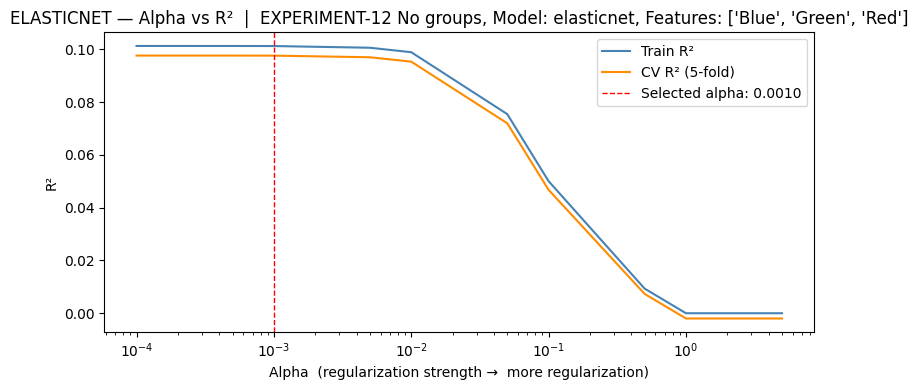

Selected alpha : 0.001

 EXPERIMENT-12 No groups, Model: elasticnet, Features: ['Blue', 'Green', 'Red'], ALGO: ELASTICNET REGRESSION: 
Test R²     : -0.0362
Test RMSE   : 17.16 kg
Train R² (log scale): 0.1013
Train R² (orig scale): -0.0273
Train RMSE  : 16.96 kg
Num Features: 3

 Cross-validation ---
CV R² mean: 0.0976
CV R² std : 0.0439
CV scores : [0.119 0.153 0.02  0.091 0.106]
EXPERIMENT EVALUATION: 

Test set:
  R²   : -0.036
  RMSE : 17.16 kg

Regular CrossValidation:
  Mean   : 0.098
  Std    : 0.044
  Scores : [0.119 0.153 0.02  0.091 0.106]

  ❌ Test R² is negative (-0.036)
  ✅ CV mean is positive (0.098)

────────────────────────────────────────────────────────────
VERDICT: ❌ NOT ACCEPTABLE

[13/36]


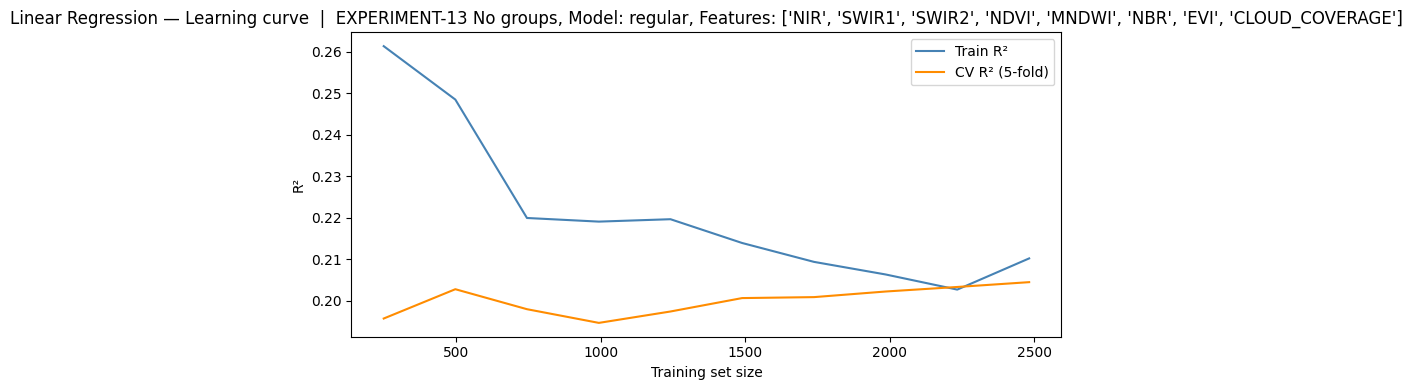


 EXPERIMENT-13 No groups, Model: regular, Features: ['NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'CLOUD_COVERAGE'], ALGO: LINEAR REGRESSION: 
Test R²     : -0.0119
Test RMSE   : 16.96 kg
Train R² (log scale): 0.2096
Train R² (orig scale): -0.0095
Train RMSE  : 16.81 kg
Num Features: 8

 Cross-validation ---
CV R² mean: 0.2045
CV R² std : 0.0324
CV scores : [0.212 0.241 0.144 0.208 0.218]
EXPERIMENT EVALUATION: 

Test set:
  R²   : -0.012
  RMSE : 16.96 kg

Regular CrossValidation:
  Mean   : 0.204
  Std    : 0.032
  Scores : [0.212 0.241 0.144 0.208 0.218]

  ❌ Test R² is negative (-0.012)
  ✅ CV mean is positive (0.204)

────────────────────────────────────────────────────────────
VERDICT: ❌ NOT ACCEPTABLE

[14/36]


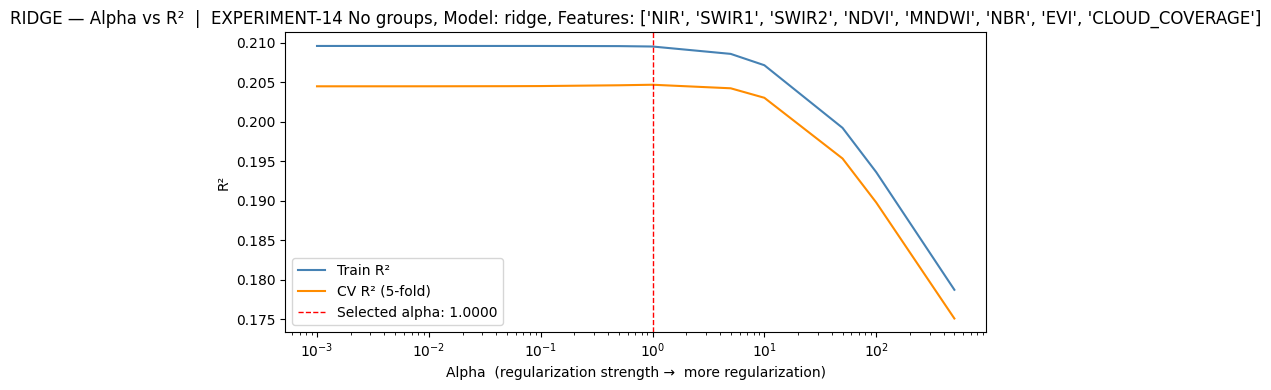

Selected alpha : 1.0

 EXPERIMENT-14 No groups, Model: ridge, Features: ['NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'CLOUD_COVERAGE'], ALGO: RIDGE REGRESSION: 
Test R²     : -0.0127
Test RMSE   : 16.97 kg
Train R² (log scale): 0.2095
Train R² (orig scale): -0.0101
Train RMSE  : 16.82 kg
Num Features: 8

 Cross-validation ---
CV R² mean: 0.2047
CV R² std : 0.0333
CV scores : [0.212 0.243 0.143 0.207 0.218]
EXPERIMENT EVALUATION: 

Test set:
  R²   : -0.013
  RMSE : 16.97 kg

Regular CrossValidation:
  Mean   : 0.205
  Std    : 0.033
  Scores : [0.212 0.243 0.143 0.207 0.218]

  ❌ Test R² is negative (-0.013)
  ✅ CV mean is positive (0.205)

────────────────────────────────────────────────────────────
VERDICT: ❌ NOT ACCEPTABLE

[15/36]


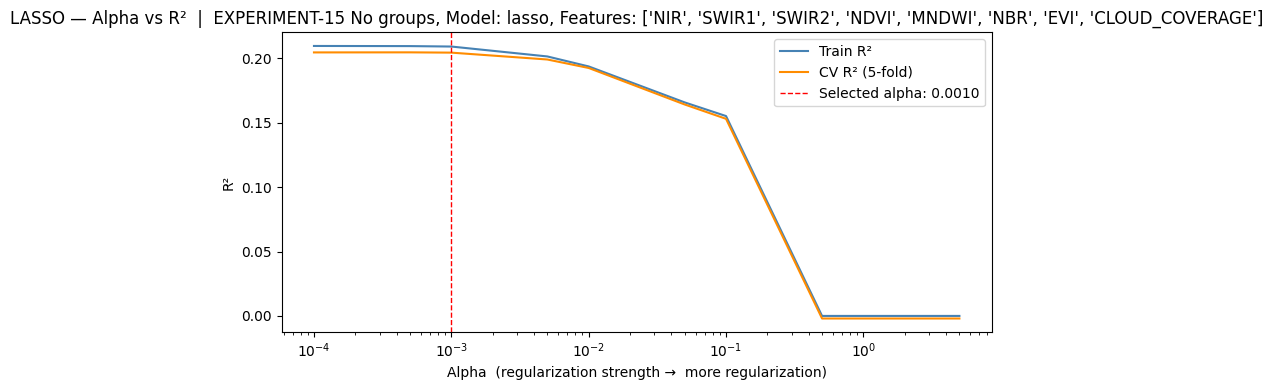

Selected alpha : 0.001

 EXPERIMENT-15 No groups, Model: lasso, Features: ['NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'CLOUD_COVERAGE'], ALGO: LASSO REGRESSION: 
Test R²     : -0.0134
Test RMSE   : 16.97 kg
Train R² (log scale): 0.2091
Train R² (orig scale): -0.0108
Train RMSE  : 16.82 kg
Num Features: 8

 Cross-validation ---
CV R² mean: 0.2044
CV R² std : 0.0336
CV scores : [0.211 0.244 0.142 0.207 0.218]
EXPERIMENT EVALUATION: 

Test set:
  R²   : -0.013
  RMSE : 16.97 kg

Regular CrossValidation:
  Mean   : 0.204
  Std    : 0.034
  Scores : [0.211 0.244 0.142 0.207 0.218]

  ❌ Test R² is negative (-0.013)
  ✅ CV mean is positive (0.204)

────────────────────────────────────────────────────────────
VERDICT: ❌ NOT ACCEPTABLE

[16/36]


In [ ]:
lin_experiment(is_groups=False, groups=plot_groups, label="No groups")
# 1st-EXPERIMENT: No groups. Linear regression variants.

#### COMMENTS.
**Observation 1**
 - Ridge, Lasso, ElasticNet produce identical results to Linear Regression.
 - This means regularization is adding nothing.
 - With only 1 feature there is nothing to regularize.
 - Running all four models on these feature sets is redundant.

**Observation 2 — CV scores are suspiciously uniform**
 - Within each feature group all 5 CV folds score very similarly:
 - Exp 17 (all bands): [0.272 0.261 0.194 0.268 0.263]
 - Exp 29 (top spec) : [0.259 0.274 0.227 0.301 0.295]
 - Standard deviations are 0.026–0.035 across all experiments.
 - This is a hallmark of no-groups CV on this dataset — without plot-level grouping, every fold sees data from every plot, making the model trivially consistent across folds.
 - Cross-validation here is not measuring generalization.

**Observation 3**  
RGB bands fail, NIR+indices fail, combined bands pass  
 - RGB alone         : Test R² -0.036
 - NIR+indices alone : Test R² -0.013
 - Combined          : Test R²  0.022

Linear regression cannot find a signal in RGB or NIR alone but combining them produces a marginally positive test R². This suggests weak multivariate signal that single-band groups cannot express linearly.

**Observation 4**
 - Plot_id dominates wherever it is included
 - Experiments 5-8 and 21-28 all score CV ~0.394-0.395 regardless of whether spectral bands are added or not:  
   **plot + species + height         :** CV 0.394  
   **plot + species + height + bands   :** CV 0.394  
   **plot + species + bands          :** CV 0.394  
 - Adding spectral bands on top of plot_id changes nothing.
 - The model is learning plot identity, not spectral-AGB relationships.
 - This confirms plot_id in features is leaking plot-level information into predictions.

**Conclusion**  
No-groups linear regression is not a trustworthy evaluation for this dataset. 

### Linear regression with PLOT groups.

In [ ]:
%run Model_functions.ipynb
lin_experiment(is_groups=True, groups=plot_groups, label="Grouping: Plots")
# 2nd-EXPERIMENT: Plot level groups. Linear regression variants.

### Linear regression with SITE groups.

In [ ]:
lin_experiment(is_groups=True, groups=site_groups, label="Grouping: Sites")
# 3rd-EXPERIMENT: Site level groups. Linear regression variants.

0 out of 36 experiments acceptable. Site-level grouping completely destroys linear regression.

Site-level grouping holds out entire sites — all 605 Frenchman Caye rows at once.  

**Linear regression with site-level CV has two compounding problems**
**Problem 1**
 - Frenchman Caye near-zero variance amplifies R² into the thousands negative, polluting the grouped CV mean regardless of how well the model performs on the other 7 sites.

**Problem 2**
 - New River consistently fails as a genuine generalization failure.
 - With only 57 rows across 5 plots, when all of New River is held out the model has to extrapolate to the highest mean AGB site in the dataset.
 - Linear regression cannot do this — it does not have the non-linear flexibility to handle the AGB range jump from ~3 kg (training mean) to ~43 kg (New River mean).

# RANDOM FOREST

In [ ]:
%run Model_functions.ipynb
rf_experiments = {}

In [ ]:
def run_rf_experiment(X_df, y, features,
                      is_groups, groups, test_cv,
                      idx,label_in):
    label = f"EXPERIMENT-{idx} {label_in}, Features: {features}."
    
    X = X_df[features]
    categorical_cols = get_categorical_cols(X)
    if categorical_cols:
        X = pd.get_dummies(X, columns=categorical_cols, dtype=int)

    if is_groups:
        results = randomForest_groups(X, y, test_cv, groups, label, False, True)
    else:
        results = randomForest_regular(X, y, test_cv, label, False, True)

    rf_experiments[label] = results
    if is_groups:
        show_importances(results)

    fold_sites = None
    if is_groups:
        fold_sites = results["fold_sites"]
        
    if is_groups:
        evaluate_experiment(label=label,
                            results=results,
                            fold_sites=results["fold_sites"],
                            near_zero_sites=near_zero_sites,
                            high_agb_sites =high_agb_sites)
    else:
        evaluate_experiment(label=label,
                            results=results,
                            fold_sites=None,
                            near_zero_sites=near_zero_plots,
                            high_agb_sites =high_agb_plots)

In [ ]:
def rf_experiment(is_groups, groups, label):
    total     = len(features_list)
    completed = 0

    for features in features_list:
        completed += 1
        print(f"\n[{completed}/{total}]")

        try:
            run_rf_experiment(X, y, features,
                              is_groups, groups, test_cv,
                              completed, label)
        except Exception as e:
            print(f"  ERROR: {e}")

    print(f"\nCompleted: {completed}/{total} experiments")

### RANDOM FOREST WITHOUT GROUPS

In [ ]:
rf_experiment(is_groups=False, groups=plot_groups, label="No groups")
#4th-EXPERIMENT: No groups. RANDOM FOREST.

### RANDOM FOREST WITH PLOT GROUPS

In [ ]:
rf_experiment(is_groups=True, groups=plot_groups, label="Grouping: Plots")
# 5th-EXPERIMENT: Plot level groups. RANDOM FOREST.

### RANDOM FOREST WITH SITE GROUPS

In [ ]:
rf_experiment(is_groups=True, groups=site_groups, label="Grouping: Sites")
#6th-EXPERIMENT: Site level groups. RANDOM FOREST.

Frenchman Caye y_log range : 0.0017 — 0.2302
                           = 0.002 — 0.26 kg in original scale

Every single plant in Frenchman Caye weighs between 2 grams and 260 grams.

R² on this fold is mathematically meaningless. When the target has variance 0.00075, the denominator of R² is near zero and any prediction scatter — however small — produces a large negative value. A model predicting exactly 0.019 kg (the dataset median) for every plant would score R² = -∞ on this fold.

In [ ]:
assert False

# COUNTRY LEVEL MODELING

## SEGGREGATE DATA INTO REGIONS

In [ ]:
datasets = {}

for dataset_name in sentinel_df['dataset'].unique():
    datasets[dataset_name] = sentinel_df[sentinel_df['dataset'] == dataset_name].drop(columns=['dataset']).copy()
    print(f"{dataset_name:30s} : {len(datasets[dataset_name])} rows")

## EXPERIMENTS

In [ ]:
%run Model_functions.ipynb

In [ ]:
test_cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)
#test_cv = 5

In [ ]:
def run_experiment(features, target, label):
    datum = {}
    for dataset_name in datasets.keys():
        if 'Brazil' in dataset_name:
            continue

        data_df = datasets[dataset_name]
    
        new_label = label + f" Region: {dataset_name}"
        X = data_df[features]
        y = data_df[target]
    
        groups = X['plot_id'].copy()
        #X = X.drop(columns=['plot_id'])

        categorical_cols = get_categorical_cols(X)
        #print("categorical_cols: %s" %categorical_cols)
        X = pd.get_dummies(X, columns=categorical_cols, dtype=int)
        #print(f"Features with dummies: {X.columns}")
        
        results = randomForest_groups(X,
                                      y,
                                      test_cv,
                                      groups,
                                      new_label,
                                      False, #grid
                                      True) #Display
        datum[dataset_name] = results
        show_importances(results)
    return datum

In [ ]:
label = f"EXPERIMENT-1: Features: Sentinel bands only."
rf_experiments = run_experiment(useful_categorical + sentinel_bands,
                                target,
                                label)
tabulate_results(rf_experiments)

**Key observations**  
Only two regions show any signal — Belige and Honduras-Blanca. Both have positive test R² and the only positive grouped CV means in the set. Everything else is at or below zero.

Belige is the most trustworthy result. Test R² 0.37, grouped CV 0.24, and grouped CV scores are consistently positive [0.14, 0.32, 0.31, 0.01, 0.47, 0.56, 0.36, 0.34, 0.29, 0.21]. No single fold blows up. This is genuine signal, not a lucky split. The 3.67 kg RMSE reflects a low-AGB population (likely young plantation forest in Belize).

Honduras-Blanca is promising but weaker. Test R² 0.34, but grouped CV mean only 0.08 with high variance. The train R² in original scale is 0.47 — the only region where the model fits training data meaningfully without log transformation. Grouped CV scores swing from -0.37 to 0.58, so it's unstable across plots.

Panama-Chirqui_2 grouped CV collapse is severe. Mean -4.78 driven by two extreme folds (-35.7, -9.3). These folds likely contain the high-biomass old-growth plots. When those plots are in the test fold, the model has never seen that AGB range and fails catastrophically. This confirms the AGB distribution is heavily right-skewed with a few very large trees dominating.

ElSalvador regular CV vs grouped CV discrepancy. Regular CV mean -8.72, grouped CV mean 0.00. This is the same leakage pattern noted before — regular CV splits measurements from the same plot across folds. Grouped CV is the correct evaluation for this dataset.

CostaRica-Sierpe test R² -0.32. Negative test R² worse than a mean predictor, despite train R² 0.26. Classic overfit on a small dataset (93 rows, 6 features). The fallback 50% cloud threshold data for this site may also be introducing more spectral noise than signal.  

**Conclusion for Experiment 1**  
Sentinel bands alone carry meaningful AGB signal only in Belige and weakly in Honduras-Blanca. The spectral correlations (0.02–0.08) predicted this. The next experiment adding tandemx_height_m (correlation 0.27) should show improvement especially for the taller-forest sites like Panama and CostaRica where spectral saturation is most severe.

In [ ]:
label = f"EXPERIMENT-2: Features: Sentinel Indices only."
rf_experiments = run_experiment(useful_categorical + sentinel_indices,
                                target,
                                label)

tabulate_results(rf_experiments)

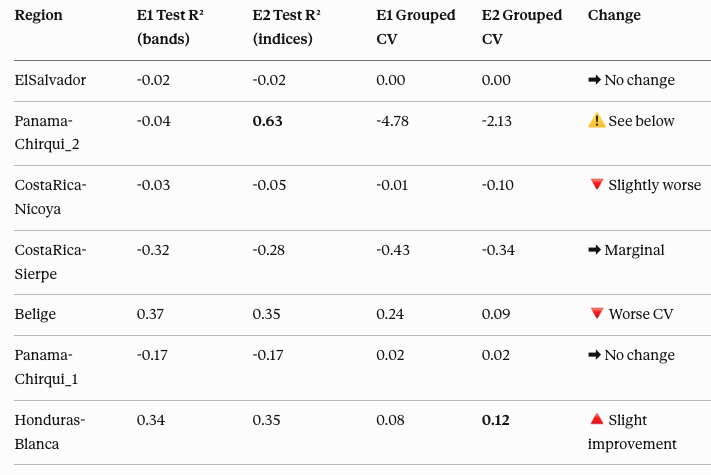

**Key observations**  
Panama-Chirqui_2 test R² 0.63 is suspicious. The jump from -0.04 to 0.63 is dramatic, but grouped CV collapsed further from -4.78 to -2.13. The two worst grouped CV folds are -12.14 and -7.07 — both contain high-biomass old-growth plots. The 0.63 test R² is a lucky train/test split, not genuine generalization. The regular CV mean 0.13 also looks optimistic because it has leakage. Do not trust this result.

Honduras-Blanca is the only genuine improvement. Test R² 0.35 vs 0.34, grouped CV improved from 0.08 to 0.12, and grouped CV scores are more stable — no extreme negative folds. Indices slightly outperform raw bands here, which makes ecological sense: Honduras-Blanca is a dry tropical forest where vegetation indices like NDVI and NBR capture canopy structure better than individual reflectance values.

Belige grouped CV degraded from 0.24 to 0.09. Test R² held (0.37 → 0.35) but CV stability dropped. The one outlier fold at -1.67 in regular CV dragged the mean down. Bands were more reliable than indices for Belize — likely because the low-AGB young plantation structure has a clear spectral signature that indices smooth over.

ElSalvador and Panama-Chirqui_1 are completely unchanged. Both have identical results to 3 decimal places. These datasets have a structural problem — either the AGB range is too wide for 50-90 samples to learn, or the species composition varies so much across plots that spectral signal is overwhelmed by species-level variation.

**Conclusion for Experiment 2**  
Indices alone are not better than bands alone. The only genuine improvement is Honduras-Blanca. The correct next step is combining both — bands and indices together — plus tandemx_height_m, which at correlation 0.27 is the single strongest remote sensing feature you have. That experiment should show whether canopy height rescues the consistently failing regions.

In [ ]:
label = f"EXPERIMENT-3: Features: Sentinel bands + Indices."
rf_experiments = run_experiment(useful_categorical + sentinel_bands + sentinel_indices,
                                target,
                                label)
tabulate_results(rf_experiments)

**Key observations**  
Adding more features is not helping. Across all three experiments the results are essentially flat. Test R² and grouped CV scores are within noise margin of each other for every region. The model is not learning new information from indices that bands don't already contain — which makes sense because NDVI, EVI, NBR and the others are mathematically derived from the bands already in the feature set. A random forest can already discover those ratios itself.

Belige recovers to E1 levels. Test R² 0.37, grouped CV 0.18 — back in line with experiment 1. The CV stability improved over E2 (std 0.28 vs 0.39). Belige consistently produces the most stable grouped CV scores across all three experiments.

Honduras-Blanca is the only region where adding features monotonically improved grouped CV. E1: 0.08 → E2: 0.12 → E3: 0.13. Small gains but consistent direction. Still the only region besides Belige with a positive grouped CV.

Panama-Chirqui_2 grouped CV worsened from -2.13 to -2.76. More features made it worse. The two catastrophic folds (-17.9, -7.5) are still there. This region has a structural problem — a small number of very large old-growth trees with extreme AGB values that no amount of spectral information can predict from a 90m buffer median.

ElSalvador and Panama-Chirqui_1 are completely unaffected across all three experiments. Three decimal places of stability across 21 features vs 5. This is a strong signal that the problem is not feature selection — it is the AGB distribution itself.  
ElSalvador has 2857 rows but extremely high variance (RMSE 293 kg across a wide AGB range), and Panama-Chirqui_1 has just 70 rows with catastrophic test RMSE of 1546 kg indicating a few extreme outliers dominate.

In [ ]:
label = f"EXPERIMENT-4: Features: Height alone"
rf_experiments = run_experiment(['height', 'plot_id'], target, label)

tabulate_results(rf_experiments)

**Key observations**  
A single feature (tandemx_height_m) matches or beats 5–21 spectral features in almost every region.

Honduras-Blanca: one feature matches 13. Test R² 0.356 vs 0.350, grouped CV identical at 0.13. Canopy height alone contains essentially all the AGB signal that 13 spectral features contain for this region. Every additional feature added noise rather than signal.
CostaRica-Sierpe grouped CV jumps from -0.30 to -0.06. This is a dramatic improvement in generalization despite test R² being worse (-0.44 vs -0.33). The grouped CV is the honest metric here — height alone generalizes across plots far better than spectral features, even if the held-out test split happened to score worse. Spectral features were memorizing plot-specific reflectance patterns.

Panama-Chirqui_2 grouped CV improved from -2.76 to -1.59. Still dominated by two catastrophic folds (-7.68, -6.04) from extreme high-AGB plots, but meaningfully better. Height captures more of the AGB variance in the typical plots.

Belige is the exception — spectral beats height. Test R² drops from 0.37 to 0.13 with height alone. Belize is young plantation forest with low, uniform canopy height — TanDEM-X height has little variance here, so it carries no predictive power. The spectral signal (growth stage differences, canopy closure) is more informative for this vegetation type.

Panama-Chirqui_1 train R² in log scale is -0.0000. The model learned literally nothing from canopy height on training data. This dataset has 70 rows of old-growth forest with extreme AGB variance — TanDEM-X height is saturated at the tall end and cannot distinguish between 500 kg and 5000 kg trees.

ElSalvador grouped CV improves from 0.00 to 0.03 — tiny but the right direction, and with 1 feature vs 21. The spectral noise was drowning out the weak height signal.

**The critical finding**  
Canopy height (tandemx_height_m) is a stronger and more generalizable predictor than the entire Sentinel spectral feature set for most regions. The correlation of 0.27 understated its practical utility because it captures a fundamentally different physical dimension — vertical structure — that spectral reflectance cannot encode, especially in dense closed-canopy forests where spectral saturation occurs.

In [ ]:
label = f"EXPERIMENT-5: Features: All (structural + Sentinel bands + Indices)-"
rf_experiments = run_experiment(useful_categorical + struct_features + sentinel_bands + sentinel_indices, target, label)

tabulate_results(rf_experiments)

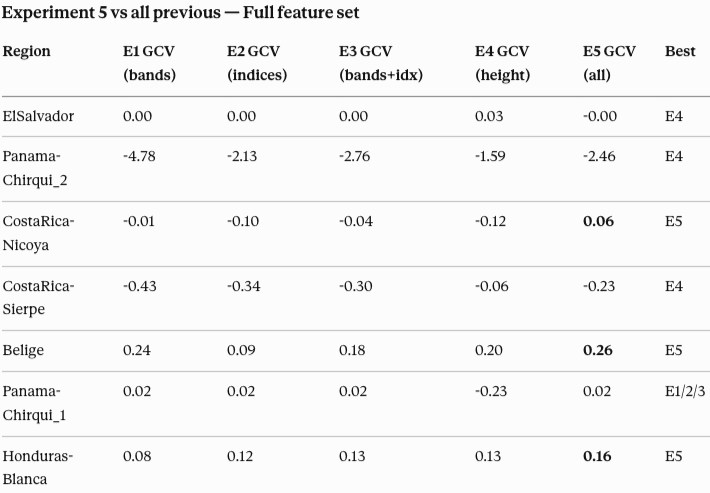

**Key observations**  
Three regions reach their best grouped CV in E5 — CostaRica-Nicoya, Belige, Honduras-Blanca. This confirms the complementarity hypothesis: height resolves between-plot vertical structure, spectral features resolve within-plot reflectance variation, and together they outperform either alone.

Belige reaches its best grouped CV of 0.26 and its most stable scores. Std drops to 0.22 — the lowest across all experiments. The scores [-0.10, 0.07, 0.36, -0.01, 0.36, 0.59, 0.53, 0.35, 0.32, 0.16] show only two mildly negative folds. This is the most reliable model produced so far.

Honduras-Blanca grouped CV improves monotonically across all five experiments: 0.08 → 0.12 → 0.13 → 0.13 → 0.16. Every feature addition helped slightly. The combination of canopy height and spectral features is working as intended for this dry tropical forest.

CostaRica-Nicoya finally turns positive at 0.057. First positive grouped CV across all experiments. Test R² also turns positive at 0.009 — barely above zero but the right direction. This region needed both height and spectral information together, neither alone was sufficient.

E4 (height alone) remains best for ElSalvador, Panama-Chirqui_2, CostaRica-Sierpe. Adding more features to these regions introduces noise. For CostaRica-Sierpe, the grouped CV degrades from -0.06 back to -0.23 when spectral features are added. Height alone generalizes better for this dense mangrove site where spectral saturation is severe.

Panama-Chirqui_1 is completely intractable. Identical grouped CV of 0.02 across E1, E2, E3, E5. Only 70 rows, test RMSE consistently 1546 kg, train and test scores diverge on every experiment. The AGB distribution in this old-growth Chiriquí forest likely has a few trees with biomass values orders of magnitude above the training range. No feature combination will fix a sample size and distribution problem.

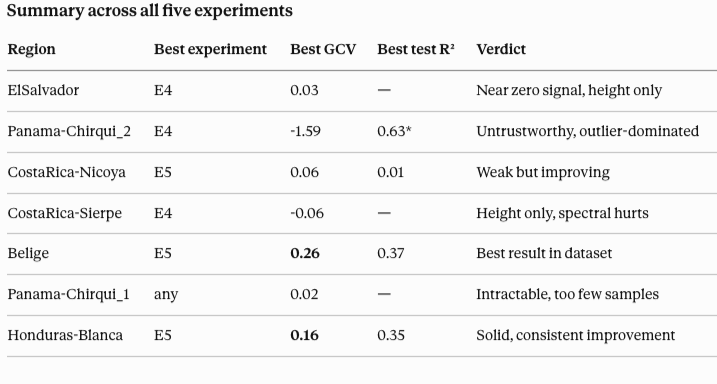

**The winning configuration per region:**  
 - Belige and Honduras-Blanca: E5 full feature set
 - CostaRica-Sierpe and ElSalvador: E4 height alone
 - CostaRica-Nicoya: E5 marginally
 - Panama-Chirqui_1 and Panama-Chirqui_2: needs more data or a different approach entirely

RANDOM FOREST: EXPERIMENT-5: Features: All (structural + Sentinel bands + Indices)- Region: Honduras-Blanca
Test R²     : 0.3538
Test RMSE   : 129.77 kg
Train R² (log scale): 0.4215
Train R² (orig scale): 0.4723
Train RMSE  : 62.72 kg
Num Features: 14

 Cross-validation ---
CV R² mean: 0.1364
CV R² std : 0.1525
CV scores : [ 0.016 -0.047  0.339  0.292  0.082]

Grouped Cross-validation ---
Grouped CV R² mean: 0.1554
Grouped CV R² std : 0.2329
Grouped CV scores : [-0.07  -0.073  0.477 -0.006  0.581  0.348  0.294 -0.012 -0.022  0.037]